В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



[Мій Python модуль](https://github.com/ShishovaInna/ML_studying/blob/main/notebooks/Modul-2/2.2%20%D0%97%D0%B0%D0%B4%D0%B0%D1%87%D0%B0%20%D0%BA%D0%BB%D0%B0%D1%81%D0%B8%D1%84%D1%96%D0%BA%D0%B0%D1%86%D1%96%D1%97/process_bank_churn.py)

In [1]:
from process_bank_churn import preprocess_data
import pandas as pd

df = pd.read_csv("/content/train.csv")
X_train, y_train, X_val, y_val, input_cols, scaler, encoder = preprocess_data(df)

In [2]:
display(X_train)
display(y_train)
display(X_val)
display(y_val)
display(input_cols)
display(scaler)
display(encoder)

array([[ 0.32018724, -0.9446819 , -1.44726392, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.34783756,  0.16122721, -1.087792  , ...,  0.        ,
         1.        ,  0.        ],
       [ 0.63816591, -0.33028795,  0.3500957 , ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.5231475 , -1.06756069,  1.06903954, ...,  0.        ,
         0.        ,  1.        ],
       [-0.95172745,  0.52986358,  0.70956762, ...,  1.        ,
         0.        ,  1.        ],
       [-1.57385963, -1.31331827, -1.087792  , ...,  0.        ,
         1.        ,  0.        ]])

,Exited
7180,0.0
10393,0.0
80,0.0
3365,0.0
12236,0.0
...,...
9493,0.0
8463,0.0
8143,0.0
11512,0.0


array([[ 0.76259235,  1.02137874, -1.44726392, ...,  0.        ,
         0.        ,  1.        ],
       [-0.91025197,  0.40698479, -0.00937623, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.99762007,  0.03834842, -1.087792  , ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 0.2648866 , -0.69892432, -0.00937623, ...,  1.        ,
         0.        ,  1.        ],
       [ 0.90084395, -0.57604553, -0.00937623, ...,  1.        ,
         0.        ,  1.        ],
       [ 0.34783756,  0.40698479, -0.00937623, ...,  0.        ,
         0.        ,  1.        ]])

,Exited
6490,1.0
3646,0.0
5306,0.0
652,0.0
2627,0.0
...,...
10550,0.0
8866,1.0
3244,0.0
12441,0.0


['CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary']

StandardScaler()

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [3]:
print(type(X_train))
print(X_train.shape)

<class 'numpy.ndarray'>
(12000, 13)


**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [4]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os

In [5]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

In [6]:
%%time
model.fit(X_train, y_train)

CPU times: user 109 ms, sys: 0 ns, total: 109 ms
Wall time: 238 ms


DecisionTreeClassifier(random_state=42)

In [7]:
from sklearn.metrics import roc_auc_score
from sklearn.tree import plot_tree, export_text

In [8]:
train_probs = model.predict_proba(X_train)[:, 1]
val_probs = model.predict_proba(X_val)[:, 1]

# Рахуємо ROC AUC
train_auc = roc_auc_score(y_train, train_probs)
val_auc = roc_auc_score(y_val, val_probs)

print(f"Train ROC AUC: {train_auc:.4f}")
print(f"Validation ROC AUC: {val_auc:.4f}")

Train ROC AUC: 1.0000
Validation ROC AUC: 0.7702


Train ROC AUC = 1.0000: Модель вивчила тренувальний датасет ідеально — до найменшого шуму та випадкових відхилень.

Validation ROC AUC = 0.7702: На нових даних, яких модель раніше не бачила, якість суттєво падає.

Висновок: Модель перенавчена (overfitted).

In [9]:
model.tree_.max_depth

26

In [10]:
model.tree_.node_count #загальна кількість усіх вузлів (nodes)

2663

In [11]:
model.get_n_leaves() #кількість кінцевого листя (Leaves)

np.int64(1332)

In [12]:
model = DecisionTreeClassifier(max_depth=2, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

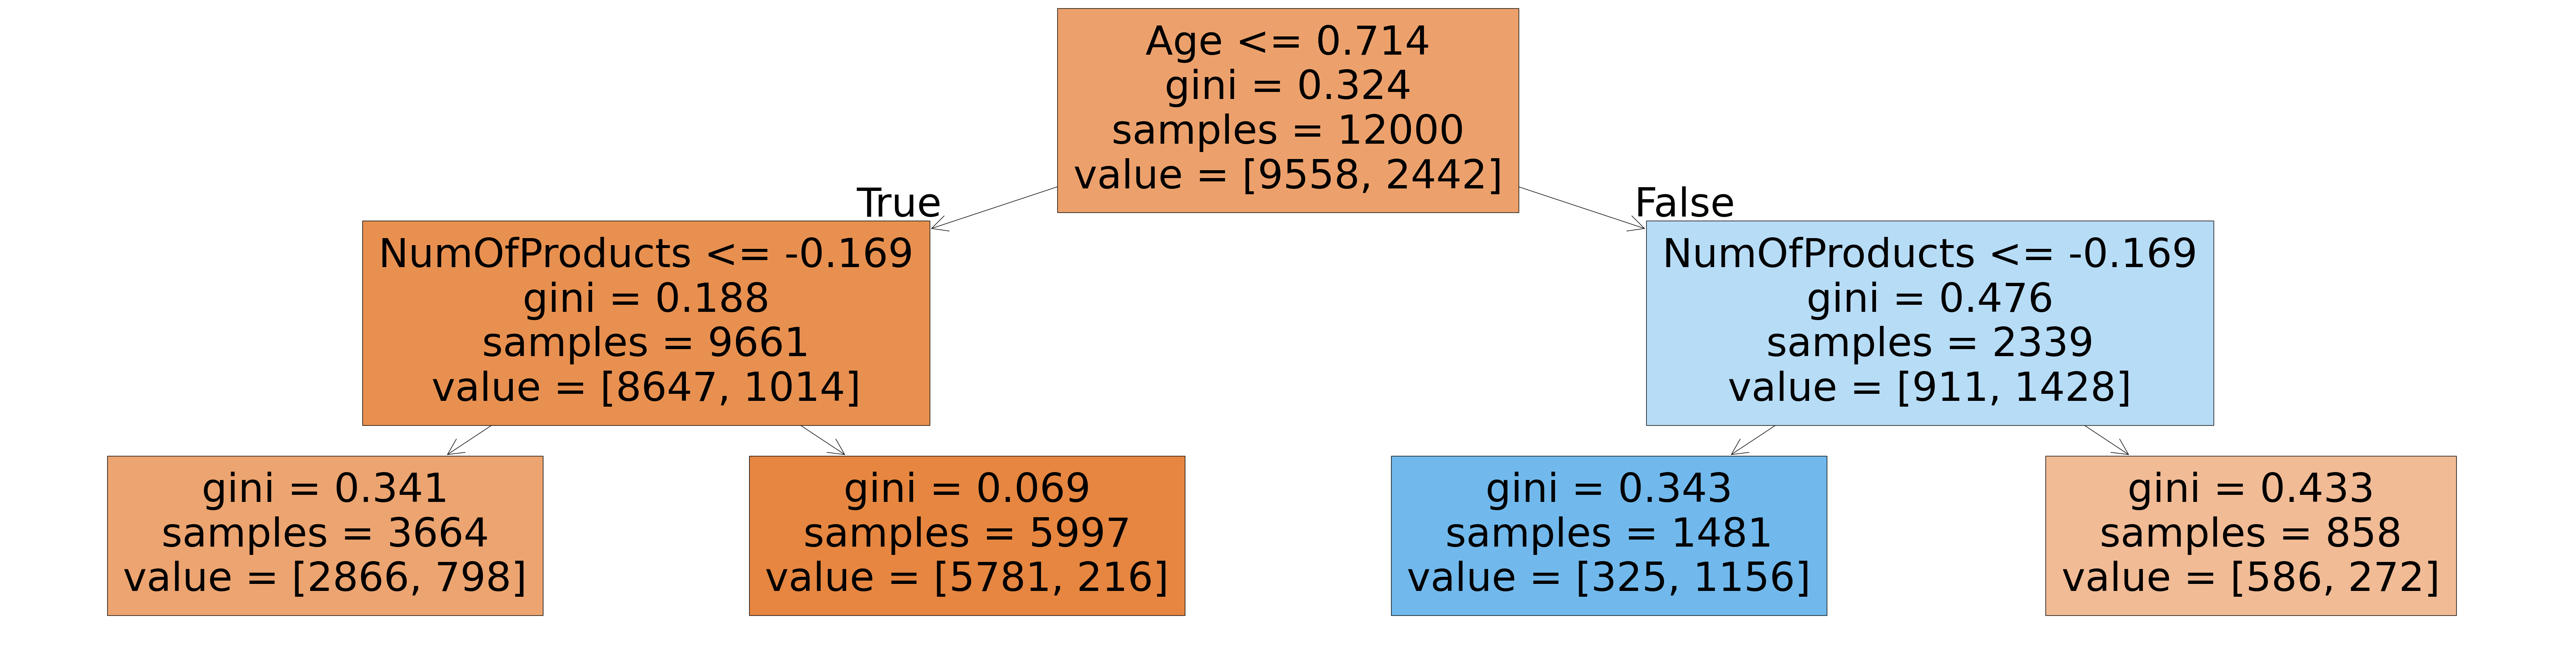

In [13]:
from process_bank_churn import get_column_types

numeric_cols, categorical_cols = get_column_types(df[input_cols])

# Повертає назви створених OneHotEncoder'ом колонок
encoded_cat_cols = encoder.get_feature_names_out().tolist()

plt.figure(figsize=(80,20))
plot_tree(model, feature_names = numeric_cols + list(encoded_cat_cols), max_depth=2, filled=True);

Найважливіши ознаки це `Age` та `NumOfProducts`  
`Age` є першою і найвпливовішою ознакою для первинного розділення  

In [14]:
model.feature_importances_.round(2)

array([0.  , 0.71, 0.  , 0.  , 0.29, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  ])

In [15]:
importance_df = pd.DataFrame({
    'feature': (numeric_cols + list(encoded_cat_cols)),
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [16]:
importance_df.head(10)

,feature,importance
1,Age,0.714962
4,NumOfProducts,0.285038
0,CreditScore,0.000000
2,Tenure,0.000000
3,Balance,0.000000
5,HasCrCard,0.000000
6,IsActiveMember,0.000000
7,EstimatedSalary,0.000000
8,Geography_France,0.000000
9,Geography_Germany,0.000000


**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [17]:
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [18]:
train_probs = model.predict_proba(X_train)[:, 1]
val_probs = model.predict_proba(X_val)[:, 1]

# Рахуємо ROC AUC
train_auc = roc_auc_score(y_train, train_probs)
val_auc = roc_auc_score(y_val, val_probs)

print(f"Train ROC AUC: {train_auc:.4f}")
print(f"Validation ROC AUC: {val_auc:.4f}")

Train ROC AUC: 0.9113
Validation ROC AUC: 0.9113


In [19]:
model = DecisionTreeClassifier(max_depth=4, max_leaf_nodes=15, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, max_leaf_nodes=15, random_state=42)

In [20]:
train_probs = model.predict_proba(X_train)[:, 1]
val_probs = model.predict_proba(X_val)[:, 1]

# Рахуємо ROC AUC
train_auc = roc_auc_score(y_train, train_probs)
val_auc = roc_auc_score(y_val, val_probs)

print(f"Train ROC AUC: {train_auc:.4f}")
print(f"Validation ROC AUC: {val_auc:.4f}")

Train ROC AUC: 0.9113
Validation ROC AUC: 0.9113


залишила такі параметри: max_depth=4, max_leaf_nodes=15

**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [21]:
def max_depth_auc(md):
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(X_train, y_train)

    train_probs = model.predict_proba(X_train)[:, 1]
    val_probs = model.predict_proba(X_val)[:, 1]

    # Рахуємо ROC AUC
    train_auc = roc_auc_score(y_train, train_probs)
    val_auc = roc_auc_score(y_val, val_probs)

    return {'Max Depth': md, 'Training AUC': train_auc, 'Validation AUC': val_auc}

In [22]:
%%time
auc_df = pd.DataFrame([max_depth_auc(md) for md in range(1, 21)])

CPU times: user 1.65 s, sys: 0 ns, total: 1.65 s
Wall time: 3.43 s


In [23]:
auc_df.style.background_gradient(subset='Validation AUC', cmap='Blues_r')

,Max Depth,Training AUC,Validation AUC
0,1,0.744727,0.734865
1,2,0.842908,0.846496
2,3,0.897184,0.891146
3,4,0.911281,0.911264
4,5,0.925694,0.921927
5,6,0.933778,0.921111
6,7,0.941535,0.914449
7,8,0.949541,0.903147
8,9,0.959079,0.884709
9,10,0.969765,0.848436


Для Max Depth = 5 найкраще значення ROC AUC:  
Training AUC = 0.925694  
Validation AUC = 0.921927

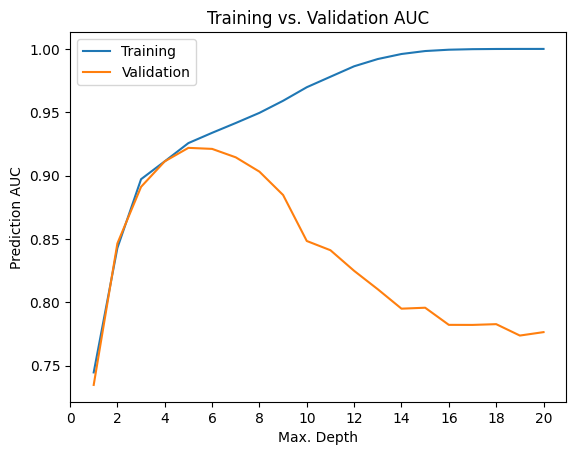

In [24]:
plt.figure()
plt.plot(auc_df['Max Depth'], auc_df['Training AUC'])
plt.plot(auc_df['Max Depth'], auc_df['Validation AUC'])
plt.title('Training vs. Validation AUC')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('Prediction AUC')
plt.legend(['Training', 'Validation']);

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [25]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [27]:
from process_bank_churn import preprocess_new_data

In [31]:
test_df = pd.read_csv("/content/test.csv")
X_test = preprocess_new_data(test_df, input_cols, scaler, encoder)
X_test

array([[-1.03467841, -0.9446819 , -1.087792  , ...,  0.        ,
         0.        ,  1.        ],
       [-1.49090867,  0.16122721, -0.00937623, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.65199107,  0.65274237,  1.06903954, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 1.59210193, -0.9446819 ,  1.42851147, ...,  0.        ,
         0.        ,  1.        ],
       [-0.88260165,  0.03834842,  0.3500957 , ...,  0.        ,
         0.        ,  1.        ],
       [ 0.01603373, -0.9446819 , -0.72832007, ...,  0.        ,
         0.        ,  1.        ]])

In [32]:
sample = pd.read_csv("/content/sample_submission.csv")
sample['Exited'] = model.predict(X_test)

# Зберігаємо готовий файл
sample.to_csv("my_submission.csv", index=False)

In [33]:
sample['Exited']

,Exited
0,0.0
1,0.0
2,0.0
3,1.0
4,0.0
...,...
9995,0.0
9996,0.0
9997,0.0
9998,0.0
